# Pillar 1 → Pillar 2: the `oneuniverse.measure` layer

`oneuniverse.measure` turns Pillar-1 OUF data into a **cosmology-free `MeasurementSet`** — the general output format Pillar-2 estimators consume. One **Universal DataProduct** with three subtypes covers the whole probe space:

| subtype | probes | from OUF geometry |
|---|---|---|
| **PointSet** | galaxy clustering, weak lensing, PV, SN | POINT |
| **Sightline** | Lyα forest | SIGHTLINE |
| **FieldMap** | CMBκ/tSZ/HI × galaxies | HEALPix/CUBE |

Each connection runs the 9-step transform (select·clean·weight·randoms·window·n(z)·photo-z·region·spec). **Cosmology enters only at the Pillar-2 estimator call** — never in the data. All synthetic OUF.

In [1]:
%matplotlib inline
import sys, tempfile
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, healpy as hp
sys.path.insert(0, str(Path.cwd().parent / 'test'))
from fixtures.measure_ouf import (synthetic_point_view, synthetic_shear_view,
    synthetic_pv_view, synthetic_sn_view, synthetic_sightline_view,
    synthetic_healpix_map)
from oneuniverse.combine.weights import FKPWeight, ColumnWeight
from oneuniverse import measure
TMP = Path(tempfile.mkdtemp())
print('measure exports:', [x for x in measure.__all__ if x.startswith('build')])

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


measure exports: ['build_galaxy_clustering', 'build_cosmic_shear', 'build_3x2pt', 'build_peculiar_velocity', 'build_sn_hubble', 'build_lya', 'build_map_cross']


## 1. Galaxy clustering (PointSet)
Catalog + FKP/completeness weights + randoms + n(z) + footprint + region.

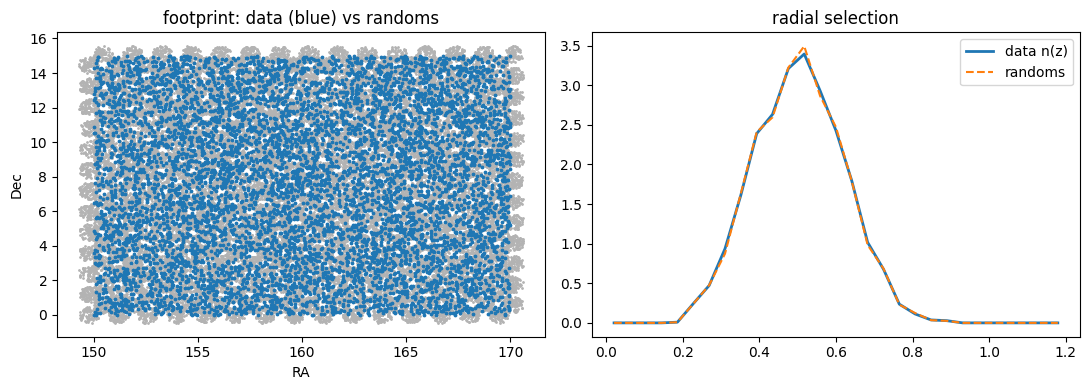

statistic: pk_multipole | randoms: generated


In [2]:
gview = synthetic_point_view(TMP, n=8000, seed=8, name='gal1')
ms = measure.build_galaxy_clustering(gview, tracer='gal', z_range=(0.2,0.9),
    weights=[FKPWeight(nbar=lambda z: np.full_like(z,1e-3), P0=1e4), ColumnWeight('weight_comp')],
    nside_window=64, nside_region=8, nz_edges=np.linspace(0,1.2,30),
    randoms='generate', n_randoms=40000, seed=1)
ps = ms.products['gal']; cat, rnd, nz = ps.catalog, ps.randoms, ps.nz
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].scatter(rnd['ra'], rnd['dec'], s=1, c='.7'); ax[0].scatter(cat['ra'], cat['dec'], s=3)
ax[0].set_title('footprint: data (blue) vs randoms'); ax[0].set_xlabel('RA'); ax[0].set_ylabel('Dec')
rh,_ = np.histogram(rnd['z'], bins=nz.edges, density=True)
ax[1].plot(nz.centers(), nz.pdf(), lw=2, label='data n(z)'); ax[1].plot(nz.centers(), rh, '--', label='randoms')
ax[1].set_title('radial selection'); ax[1].legend(); plt.tight_layout(); plt.show()
print('statistic:', ms.spec.statistic, '| randoms:', ps.provenance.randoms_source); ms.check_invariants()

## 2. Weak lensing — cosmic shear (PointSet + shapes + photo-z kernel)
Source shapes (`e1,e2` + metacal calibration) + per-object p(z) + tomographic n(z).

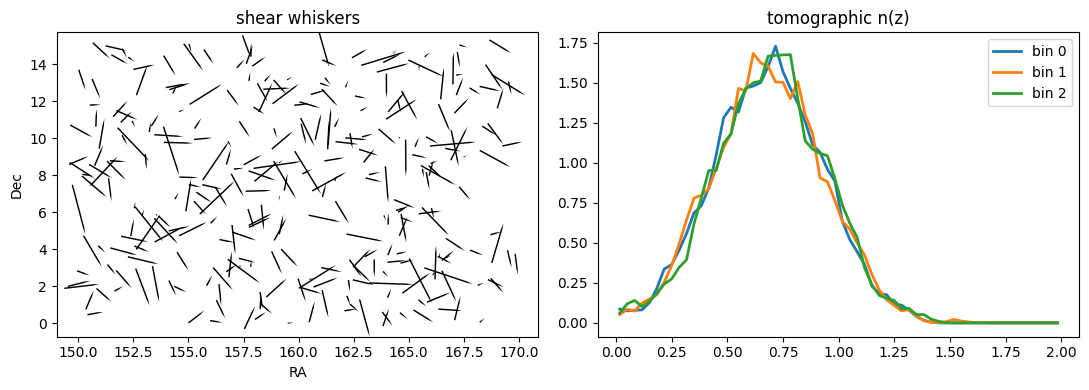

photoz kernel: ProbabilisticRedshift | weight: <ShearWeight name='shear_weight(metacal)'>


In [3]:
sview = synthetic_shear_view(TMP, n=6000, seed=3, kind='metacal', with_pdf=True, n_tomo=3, name='src1')
ms = measure.build_cosmic_shear(sview, tracer='src', kind='metacal',
    tomo_column='tomo_bin', z_grid=np.linspace(0,2,61), nside_region=8)
ps = ms.products['src']; cat = ps.catalog
fig, ax = plt.subplots(1,2, figsize=(11,4))
s = cat.iloc[::20]; emag=np.hypot(s['e1'],s['e2']); a=0.5*np.arctan2(s['e2'],s['e1'])
ax[0].quiver(s['ra'], s['dec'], emag*np.cos(a), emag*np.sin(a), headwidth=0, headlength=0, pivot='mid', scale=8, width=0.003)
ax[0].set_title('shear whiskers'); ax[0].set_xlabel('RA'); ax[0].set_ylabel('Dec')
for b,n in sorted(ps.nz.items()): ax[1].plot(n.centers(), n.pdf(), lw=2, label=f'bin {b}')
ax[1].set_title('tomographic n(z)'); ax[1].legend(); plt.tight_layout(); plt.show()
print('photoz kernel:', type(ps.photoz).__name__, '| weight:', ps.provenance.weight_recipe[0]); ms.check_invariants()

## 3. Peculiar velocities + SN Ia (PointSet + distance atoms)
Distance indicators (v_pec, μ, σ_v) and a lazy row-correlated covariance handle.

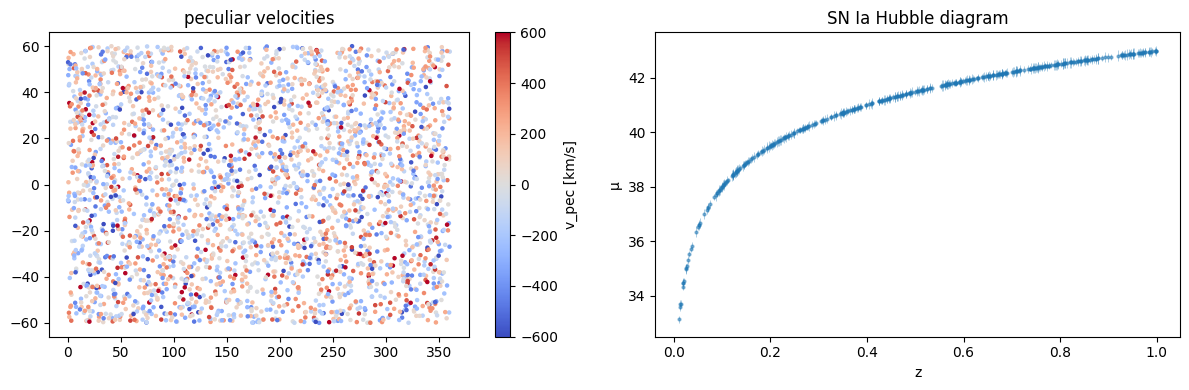

PV family: velocity | SN statistic: hubble


In [4]:
pv = measure.build_peculiar_velocity(synthetic_pv_view(TMP, n=3000, seed=3, name='pv1'),
    z_range=(0,0.1), nside_region=8)
snv,_ = synthetic_sn_view(TMP, n=400, seed=4, name='sn1')
sn = measure.build_sn_hubble(snv, z_range=(0,1.5), nside_region=4)
pcat, scat = pv.products['pv'].catalog, sn.products['sn'].catalog
fig, ax = plt.subplots(1,2, figsize=(12,4))
sc=ax[0].scatter(pcat['ra'], pcat['dec'], s=5, c=pcat['v_pec'], cmap='coolwarm', vmin=-600, vmax=600)
ax[0].set_title('peculiar velocities'); plt.colorbar(sc, ax=ax[0], label='v_pec [km/s]')
ax[1].errorbar(scat['z'], scat['mu'], yerr=scat['mu_err'], fmt='.', ms=4, alpha=.5, elinewidth=.5)
ax[1].set_title('SN Ia Hubble diagram'); ax[1].set_xlabel('z'); ax[1].set_ylabel('μ'); plt.tight_layout(); plt.show()
print('PV family:', pv.spec.estimator_family, '| SN statistic:', sn.spec.statistic)

## 4. Lyα forest (Sightline subtype)
Per-line-of-sight δ_F(λ) + weights + continuum — the non-point geometry.

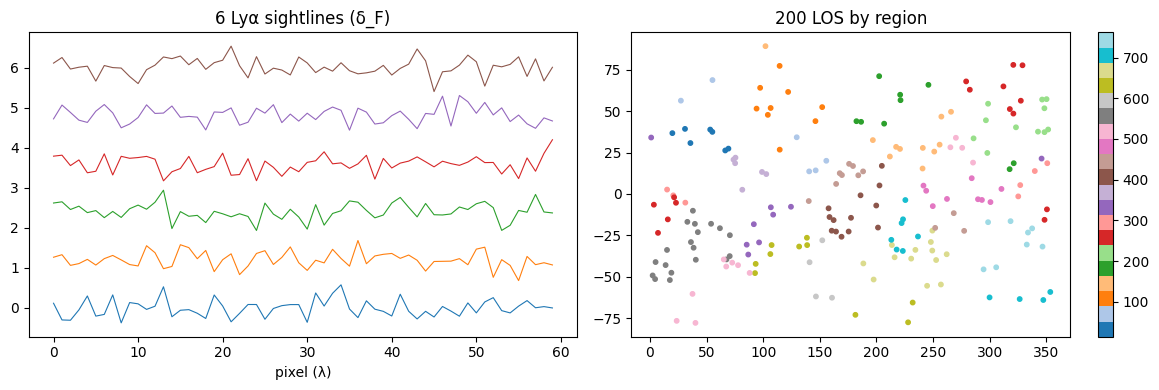

subtype: sightline | statistic: p1d


In [5]:
lview = synthetic_sightline_view(TMP, n_los=200, n_pix=60, seed=2, name='lya1')
ms = measure.build_lya(lview, statistic='p1d', nside_region=8)
sl = ms.products['lya']
fig, ax = plt.subplots(1,2, figsize=(12,4))
for i in range(6): ax[0].plot(sl.delta[i] + i*1.2, lw=.8)
ax[0].set_title('6 Lyα sightlines (δ_F)'); ax[0].set_xlabel('pixel (λ)')
sc=ax[1].scatter(sl.los['ra'], sl.los['dec'], s=10, c=sl.los['region_id'], cmap='tab20')
ax[1].set_title(f'{sl.n_sightlines} LOS by region'); plt.colorbar(sc, ax=ax[1]); plt.tight_layout(); plt.show()
print('subtype:', sl.kind, '| statistic:', ms.spec.statistic); ms.check_invariants()

## 5. Map × catalog (FieldMap subtype)
A HEALPix field (CMBκ / tSZ y) crossed with the galaxy catalog → C_ℓ.

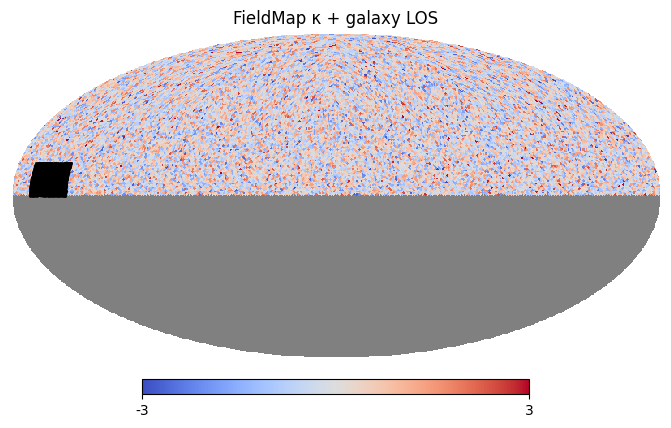

products: {'gal', 'kappa'} | pairs: (('gal', 'kappa'),) | statistic: cl


In [6]:
from oneuniverse.measure.fieldmap import fieldmap_from_healpix
vals, mask = synthetic_healpix_map(nside=64, seed=4)
fmap = fieldmap_from_healpix(vals, mask=mask, nside=64, dataset_id='cmbk')
ms = measure.build_map_cross(synthetic_point_view(TMP, n=6000, seed=3, name='gal2'),
    fmap, nside_region=8, z_range=(0.1,1.0))
gcat = ms.products['gal'].catalog
masked = np.where(fmap.mask, fmap.values, hp.UNSEEN)
fig = plt.figure(figsize=(10,5))
hp.mollview(masked, nest=True, fig=fig.number, title='FieldMap κ + galaxy LOS', cmap='coolwarm', min=-3, max=3, hold=True)
hp.projscatter(np.radians(90-gcat['dec'].to_numpy()), np.radians(gcat['ra'].to_numpy()), s=1, c='k', alpha=.4)
plt.show()
print('products:', set(ms.products), '| pairs:', ms.spec.pairs, '| statistic:', ms.spec.statistic); ms.check_invariants()

## Summary
Five probe connections, one cosmology-free contract:

| probe | builder | subtype | statistic |
|---|---|---|---|
| galaxy clustering | `build_galaxy_clustering` | PointSet | pk_multipole |
| cosmic shear / 3×2pt | `build_cosmic_shear`/`build_3x2pt` | PointSet | xi_pm / mixed |
| peculiar velocity | `build_peculiar_velocity` | PointSet | velocity |
| SN Ia | `build_sn_hubble` | PointSet | hubble |
| Lyα forest | `build_lya` | Sightline | p1d / p3d |
| map × catalog | `build_map_cross` | PointSet × FieldMap | cl |

Every `MeasurementSet` carries data + randoms + n(z) + window + weights + shared region map + provenance — **no cosmology**. Estimator-side adapters (flip / pycorr / picca) are a separate, later layer; the format is the standard they adopt.

**Honest caveat:** all synthetic OUF — real DESI/eBOSS validation is the pending follow-up.